In [1]:
from sctoolbox.utils.jupyter import bgcolor, _compare_version

# change the background of input cells
bgcolor("PowderBlue", select=[3, 5, 12, 13, 14, 18])

nb_name = "04_clustering.ipynb"

_compare_version(nb_name)

# 04 - Embedding and clustering
<hr style="border:2px solid black"> </hr>

## 1 - Description
This notebook aims to group cells based on how similar their gene expression profiles are. Ideally, the resulting clusters should represent different cell types. This grouping is achieved in two steps: **Embedding** and **Clustering**.

### 1.1 Embedding
Embeddings are dimension reduction methods to transform high-dimensional data into lower-dimensional representations while preserving the inherent structure and relationships between individual cells.  
The sctoolbox supports the [Uniform Manifold Approximation and Projection (UMAP)](https://arxiv.org/abs/1802.03426) and the [t-distributed stochastic neighbor embedding (t-SNE)](https://www.jmlr.org/papers/volume9/vandermaaten08a/vandermaaten08a.pdf) methods for dimension reduction, with UMAP being set as the default value.
To learn more about the differences between those methods and get more insight in the parameter selction have a look [here for umap](https://pair-code.github.io/understanding-umap/) and [here for t-SNE](https://distill.pub/2016/misread-tsne/?_ga=2.135835192.888864733.1531353600-1779571267.1531353600).
### 1.2 Clustering
Single cell clustering is used to group individual cells into clusters based on similarities in their gene expression. The clustering allows to identify distinct cell types and characterize cellular heterogeneity within a population.
The sctoolbox supports the [leiden](https://www.nature.com/articles/s41598-019-41695-z) and the [louvain](https://iopscience.iop.org/article/10.1088/1742-5468/2008/10/P10008) clustering methods, with the leiden clustering algorithm being newer and recommended to use.

-----------

## 2 - Setup

In [2]:
import scanpy as sc
import pandas as pd

import sctoolbox
import sctoolbox.utils as utils
import sctoolbox.tools as tools
import sctoolbox.plotting as pl

sctoolbox.settings.settings_from_config("config.yaml", key="04")

# Set additional options for figures
sc.set_figure_params(vector_friendly=True, dpi_save=600, scanpy=False)

[WARNING] Log file '../logs/04_log.txt' already exists. The file will be overwritten since 'overwrite_log' is set to True.


-----------

## 3 - Load anndata

In [3]:
adata = utils.adata.load_h5ad("anndata_3.h5ad")

with pd.option_context("display.max.rows", 5, "display.max.columns", None):
    display(adata)
    display(adata.obs)
    display(adata.var)

[INFO] The adata object was loaded from: ../adatas/anndata_3.h5ad


AnnData object with n_obs × n_vars = 3449 × 55535
    obs: 'TubeID', 'meta_TubeID', 'meta_pop_export_psn', 'meta_pop_visit_1_date', 'meta_pop_visit_2_date', 'meta_pop_visit_3_date', 'meta_pop_visit_4_date', 'meta_pop_age', 'meta_pop_age_dec', 'meta_pop_sex', 'meta_pop_c19_severity', 'meta_pop_cohort', 'meta_suep_hap_export_psn', 'meta_suep_hap_baseline_date', 'meta_suep_hap_end_acute_date', 'meta_suep_hap_end_acute_visit_date', 'meta_suep_hap_m3_fu_date', 'meta_suep_hap_m6_fu_date', 'meta_suep_hap_m12_fu_date', 'meta_suep_hap_m24_fu_date', 'meta_suep_hap_age', 'meta_suep_hap_age_dec', 'meta_suep_hap_sex', 'meta_suep_hap_c19_severity', 'meta_suep_hap_cohort', 'meta_export_psn', 'meta_age', 'meta_age_dec', 'meta_sex', 'meta_c19_severity', 'meta_cohort', 'rna_TubeID', 'rna_id', 'rna_fastq1', 'rna_project', 'rna_run', 'rna_plate', 'rna_organism', 'rna_assembly', 'rna_release', 'rna_parameters', 'rna_reads_processed', 'rna_reads_with_exactly_1_alignment', 'rna_reads_with_multiple_alignments

,TubeID,meta_TubeID,meta_pop_export_psn,meta_pop_visit_1_date,meta_pop_visit_2_date,meta_pop_visit_3_date,meta_pop_visit_4_date,meta_pop_age,meta_pop_age_dec,meta_pop_sex,meta_pop_c19_severity,meta_pop_cohort,meta_suep_hap_export_psn,meta_suep_hap_baseline_date,meta_suep_hap_end_acute_date,meta_suep_hap_end_acute_visit_date,meta_suep_hap_m3_fu_date,meta_suep_hap_m6_fu_date,meta_suep_hap_m12_fu_date,meta_suep_hap_m24_fu_date,meta_suep_hap_age,meta_suep_hap_age_dec,meta_suep_hap_sex,meta_suep_hap_c19_severity,meta_suep_hap_cohort,meta_export_psn,meta_age,meta_age_dec,meta_sex,meta_c19_severity,meta_cohort,rna_TubeID,rna_id,rna_fastq1,rna_project,rna_run,rna_plate,rna_organism,rna_assembly,rna_release,rna_parameters,rna_reads_processed,rna_reads_with_exactly_1_alignment,rna_reads_with_multiple_alignments,rna_reads_with_no_alignment,rna_reads_aligned,rna_pct_reads_aligned,rna_duplicate_reads,rna_pct_duplicate_reads,rna_mitochondrial_reads,rna_pct_mitochondrial_reads,rna_rrna_subunit_reads,rna_pct_rrna_subunit_reads,rna_pcr_bottleneck_coefficient,rna_mean_fragment_size_(only_for_paired-end),rna_reads_used_after_filters,rna_parameters.1,rna_reads_processed.1,rna_reads_assigned,rna_pct_reads_assigned_total,rna_pct_features_with_cpm_at_least_0.5,rna_unass._reads_overlapping_multiple_genes,rna_unass._reads_mapping_to_multiple_locations,rna_unass._reads_mapping_to_no_feature,rna_unass._reads_not_mapping,rna_unass._reads__bad_mapping_quality,rna_unass._reads__low_fragment_length,rna_unass._chimeric_reads,mapped_reads_over_2000000,rna_DDX3Y,rna_XIST,rna_gender,rna_sample_id_original,rna_plate_id_original,filename,rel_path,total_counts,log1p_total_counts,total_counts_is_mito,log1p_total_counts_is_mito,pct_counts_is_mito,total_counts_is_ribo,log1p_total_counts_is_ribo,pct_counts_is_ribo,total_counts_is_gender,log1p_total_counts_is_gender,pct_counts_is_gender,n_genes,log1p_n_genes,S_score,G2M_score,phase,leiden,LISI_score_X_pca,LISI_score_X_umap
rna project.run id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
plt1.run1 pat_88,LV1007699778,LV1007699778,0,0,0,0,0,0.0,0,0,0,0,hap_0178,17/11/2021,24/11/2021,24/11/2021,0,0,0,0,65.0,60-69,M,severe,hap,hap_0178,65.0,60-69,M,severe,hap,LV1007699778,pat_88,AAAVY52HV_NAPKON_Plate1_2_22s004137-1-1_Valasa...,plt1,run1,plate1,human,hg38,104.0,"mode: single-end, keep duplicates: no, keep mu...","29,112,743","23,152,813","4,044,454","1,915,476","27,197,267",93.0,"20,093,139",73.0,"1,714,158",6.0,"1,868,907",6.0,0.28,0.0,"6,644,895",-t exon -g gene_id -s 2; multi-mapping: no; du...,"6,644,895","4,810,861",16.0,49.0,216.360,0.0,"1,617,674",0.0,0.0,0.0,0.0,True,844.0,8.0,M,Sample 49,Plate 1,matrix.mtx,.,4810335.0,15.386277,0.0,0.0,0.0,52602.0,10.870528,1.093521,155239.0,11.952727,3.227197,23151,10.049836,0.550765,0.358594,S,0,9.782188,10.508994
plt1.run1 pat_89,LV1007699743,LV1007699743,0,0,0,0,0,0.0,0,0,0,0,suep_0425,08/11/2021,17/11/2021,17/11/2021,0,0,0,0,61.0,60-69,M,mild,suep,suep_0425,61.0,60-69,M,mild,suep,LV1007699743,pat_89,AAAVY52HV_NAPKON_Plate1_2_22s004137-1-1_Valasa...,plt1,run1,plate1,human,hg38,104.0,"mode: single-end, keep duplicates: no, keep mu...","24,355,220","13,253,462","7,713,379","3,388,379","20,966,841",86.0,"17,678,467",84.0,"1,475,002",7.0,"6,372,269",30.0,0.22,0.0,"2,989,995",-t exon -g gene_id -s 2; multi-mapping: no; du...,"2,989,995","2,155,768",8.0,45.0,97.961,0.0,"736,266",0.0,0.0,0.0,0.0,True,670.0,4.0,M,Sample 50,Plate 1,matrix.mtx,.,2155449.0,14.583510,0.0,0.0,0.0,31098.0,10.344931,1.442762,71203.0,11.173305,3.303395,20116,9.909321,1.236655,0.921511,S,0,9.078315,9.124080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

,Ensembl_gene_id,Ensembl_biotype,UniProt_proteins,UniProt_genes,UniProt_accessions,UniProt_names,UniProt_Ensembl_transcripts,UniProt_Ensembl_proteins,UniProt_Ensembl_gene_ids,Ensembl_chr,Ensembl_start,Ensembl_stop,Ensembl_strand,KEGG_PATHWAY_terms,KEGG_PATHWAY_ids,Gene_Ontology_terms,Gene_Ontology_ids,is_mito,is_ribo,is_gender,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable,means,dispersions,dispersions_norm,mean,std
Ensembl gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
SDK1,ENSG00000146555,protein_coding,Protein sidekick-1,SDK1,Q7Z5N4; F8W6X9; A0A087WTQ6,SDK1_HUMAN; F8W6X9_HUMAN; A0A087WTQ6_HUMAN,ENST00000404826; ENST00000389531; ENST00000615806,ENSP00000385899; ENSP00000374182; ENSP00000478062,ENSG00000146555,chr7,3301252,4269000,+,0,0,"eye development, neural retina development, bi...","GO:0001654, GO:0003407, GO:0005488, GO:0005515...",False,False,False,2524,2.502754,1.253550,26.819368,8632.0,9.063348,False,1.191707,1.026539,0.046556,0.941522,0.710344
ENSG00000283537,ENSG00000283537,transcribed_unprocessed_pseudogene,0,0,0,0,0,0,ENSG00000283537,chr7,143620943,143645675,+,0,0,0,0,False,False,False,782,0.491447,0.399747,77.326761,1695.0,7.436028,False,0.368743,0.892386,0.027690,0.228287,0.459515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000270696,ENSG00000270696,lncRNA,0,0,0,0,0,0,ENSG00000270696,chr2,75660462,75662208,+,0,0,0,0,False,False,False,1,0.000290,0.000290,99.971006,1.0,0.693147,False,0.000474,0.491737,-0.777342,0.000281,0.016499
SNRPGP11,ENSG00000229906,processed_pseudogene,0,0,0,0,0,0,ENSG00000229906,chr13,51496020,51496251,-,0,0,0,0,False,False,False,1,0.000290,0.000290,99.971006,1.0,0.693147,False,0.000488,0.521551,-0.717437,0.000286,0.016816


------------

## 4 - General input
Choose the embedding and clustering method and adjust the range of parameters for each one of them. The specific parameters for **embedding** (`section 5`) and **clustering** (`section 7`) can be chosen after visually inspecting the results.

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [4]:
# Column to show in UMAPs
condition_column = "meta_c19_severity"

# Number of threads to use for multiprocessing
threads = 4

# Search embedding parameters (or set parameters later)
embedding = "umap"   # umap or tsne
search_parameters = True

# UMAP parameters
dist_range = (0.1, 0.31, 0.1)  # Set min_dist range for umap
spread_range = (1, 2.5, 0.5)  # Set spread range for umap
n_components = 2  # Number of components for umap (>=3 enables 3d UMAP but likely degrades 2d results)

# t-SNE parameters
perplexity_range = (30, 60, 10)  # perplexity range for tsne
learning_rate_range = (400, 1000, 200)  # learning_rate for tsne

# Search different clustering resolutions
search_clustering_parameters = True
cluster_res_range = (0.1, 1, 0.1)  # Set the searched resolution range from low to high resolution (less to more clusters).
clustering_method = "leiden"  # leiden or louvain
cluster_ncols = 4  # Number of columns displayed in the plot

_____________

## 5 - Calculate UMAP/TSNE and find the best setting
<hr style="border:2px solid black"> </hr>

After visually inspecting the results, adjust the parameters shown below for the best embedding. While it is somewhat subjective what the "best" parameters for an embedding should be, the chosen embedding should display clear structures that are neither spread too thin nor too clumped up.

### 5.1 Parameter overview

|Method|Parameter|Description|
|------|---------|-----------|
|[UMAP](https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.umap.html)|`min_dist`|Distances between points to make the plot look more 'clustered'.|
|[UMAP](https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.umap.html)|`spread`|The effective scale of embedded points. Relative to `min_dist`|
|[tSNE](https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.tsne.html)|`perplexity`|Related to the number of nearest-neighbors accounted for during embedding creation. Larger datasets require bigger values.|
|[tSNE](https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.tsne.html)|`learning_rate`|Can be important for embedding cluster formation.|

Computing UMAPs:   0%|          | 0/9 [00:00<?, ?it/s]

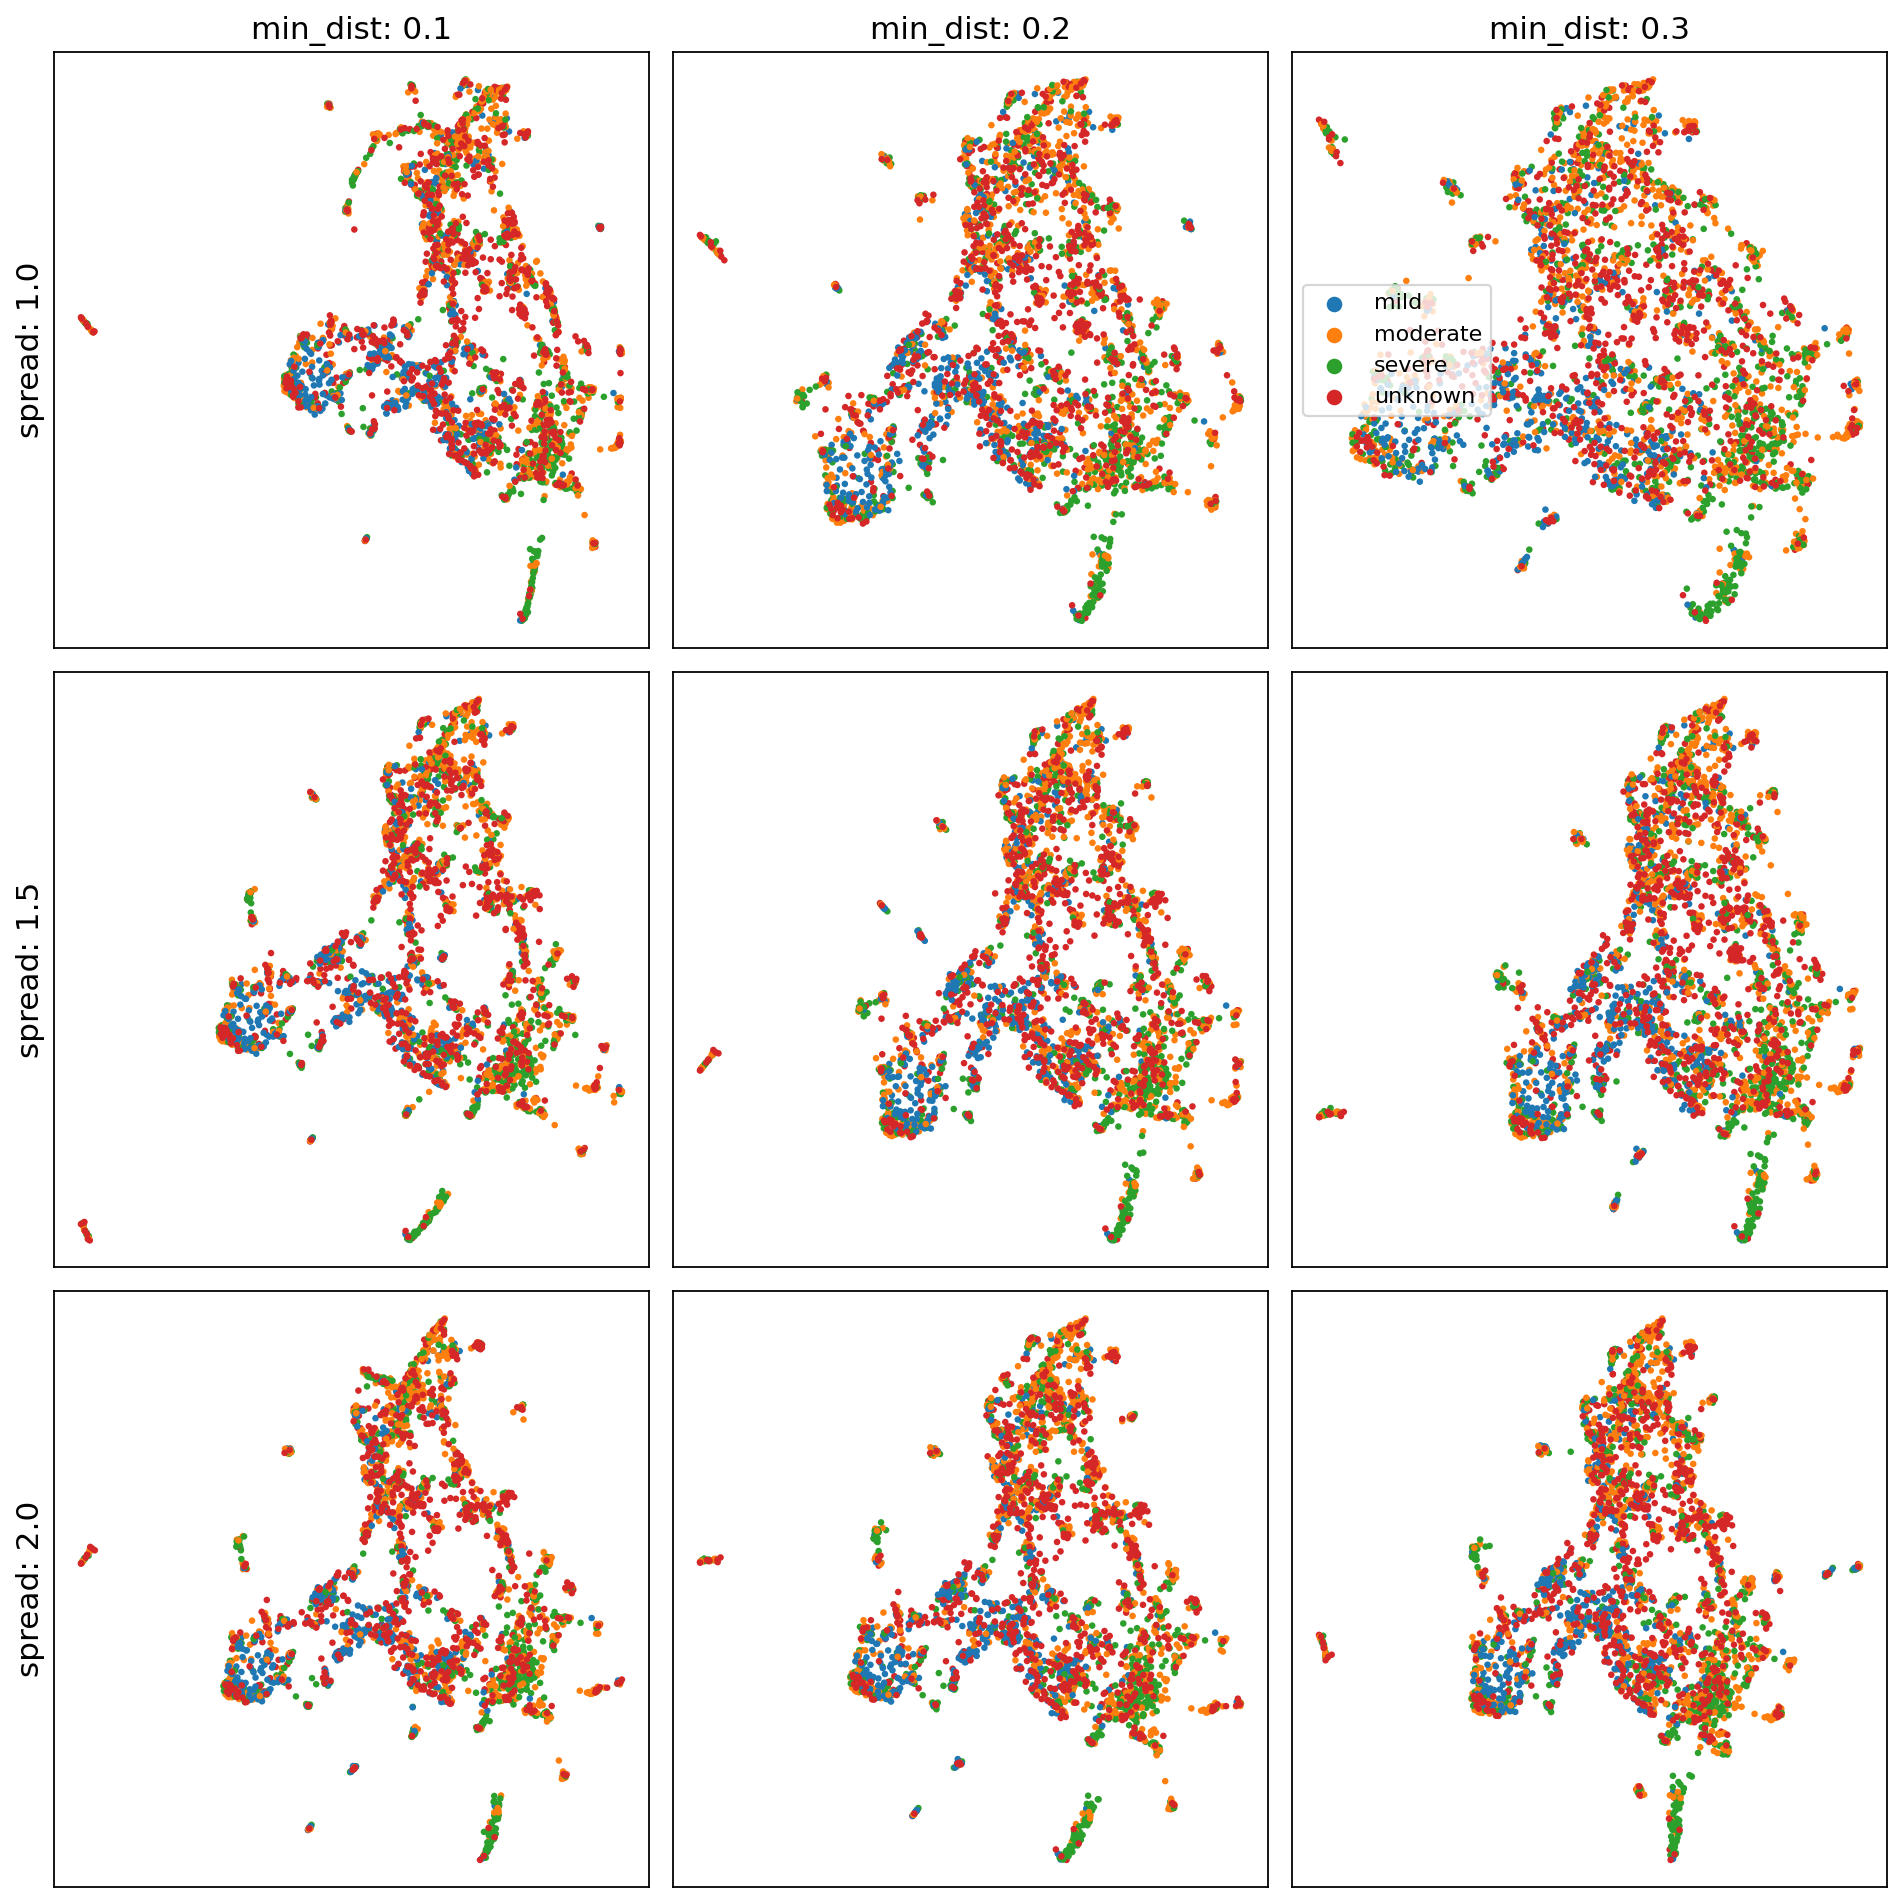

In [5]:
if search_parameters:
    if embedding == "umap":
        pl.embedding.search_umap_parameters(
            adata, 
            min_dist_range=dist_range,
            spread_range=spread_range,
            color=condition_column,
            n_components=n_components,
            threads=threads,
            save="UMAP_parameter_search.pdf"
        )
    elif embedding == "tsne":
        pl.embedding.search_tsne_parameters(
            adata, 
            perplexity_range=perplexity_range,
            learning_rate_range=learning_rate_range,
            color=condition_column,
            threads=threads,
            save="TSNE_parameter_search.pdf"
        )

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [6]:
# Final choice of spread / dist for umap
min_dist = 0.4
spread = 2.5

# Final choice of perplexity / learning_rate for tsne
perplexity = 50
learning_rate = 800

___

In [8]:
# Calculate final embedding
if embedding == "umap":
    sc.tl.umap(adata, min_dist=min_dist, spread=spread, n_components=n_components)
elif embedding == "tsne":
    sc.tl.tsne(adata, perplexity=perplexity, learning_rate=learning_rate)

___

## 6 - Plot final embedding with quality measures

In [9]:
# Adjust qc columns to show in plot
qc_columns = [k for k in adata.uns["sctoolbox"]["report"]["qc"]["obs"]["threshold"].keys() if k not in ["before", "after"]] + ["phase", condition_column]

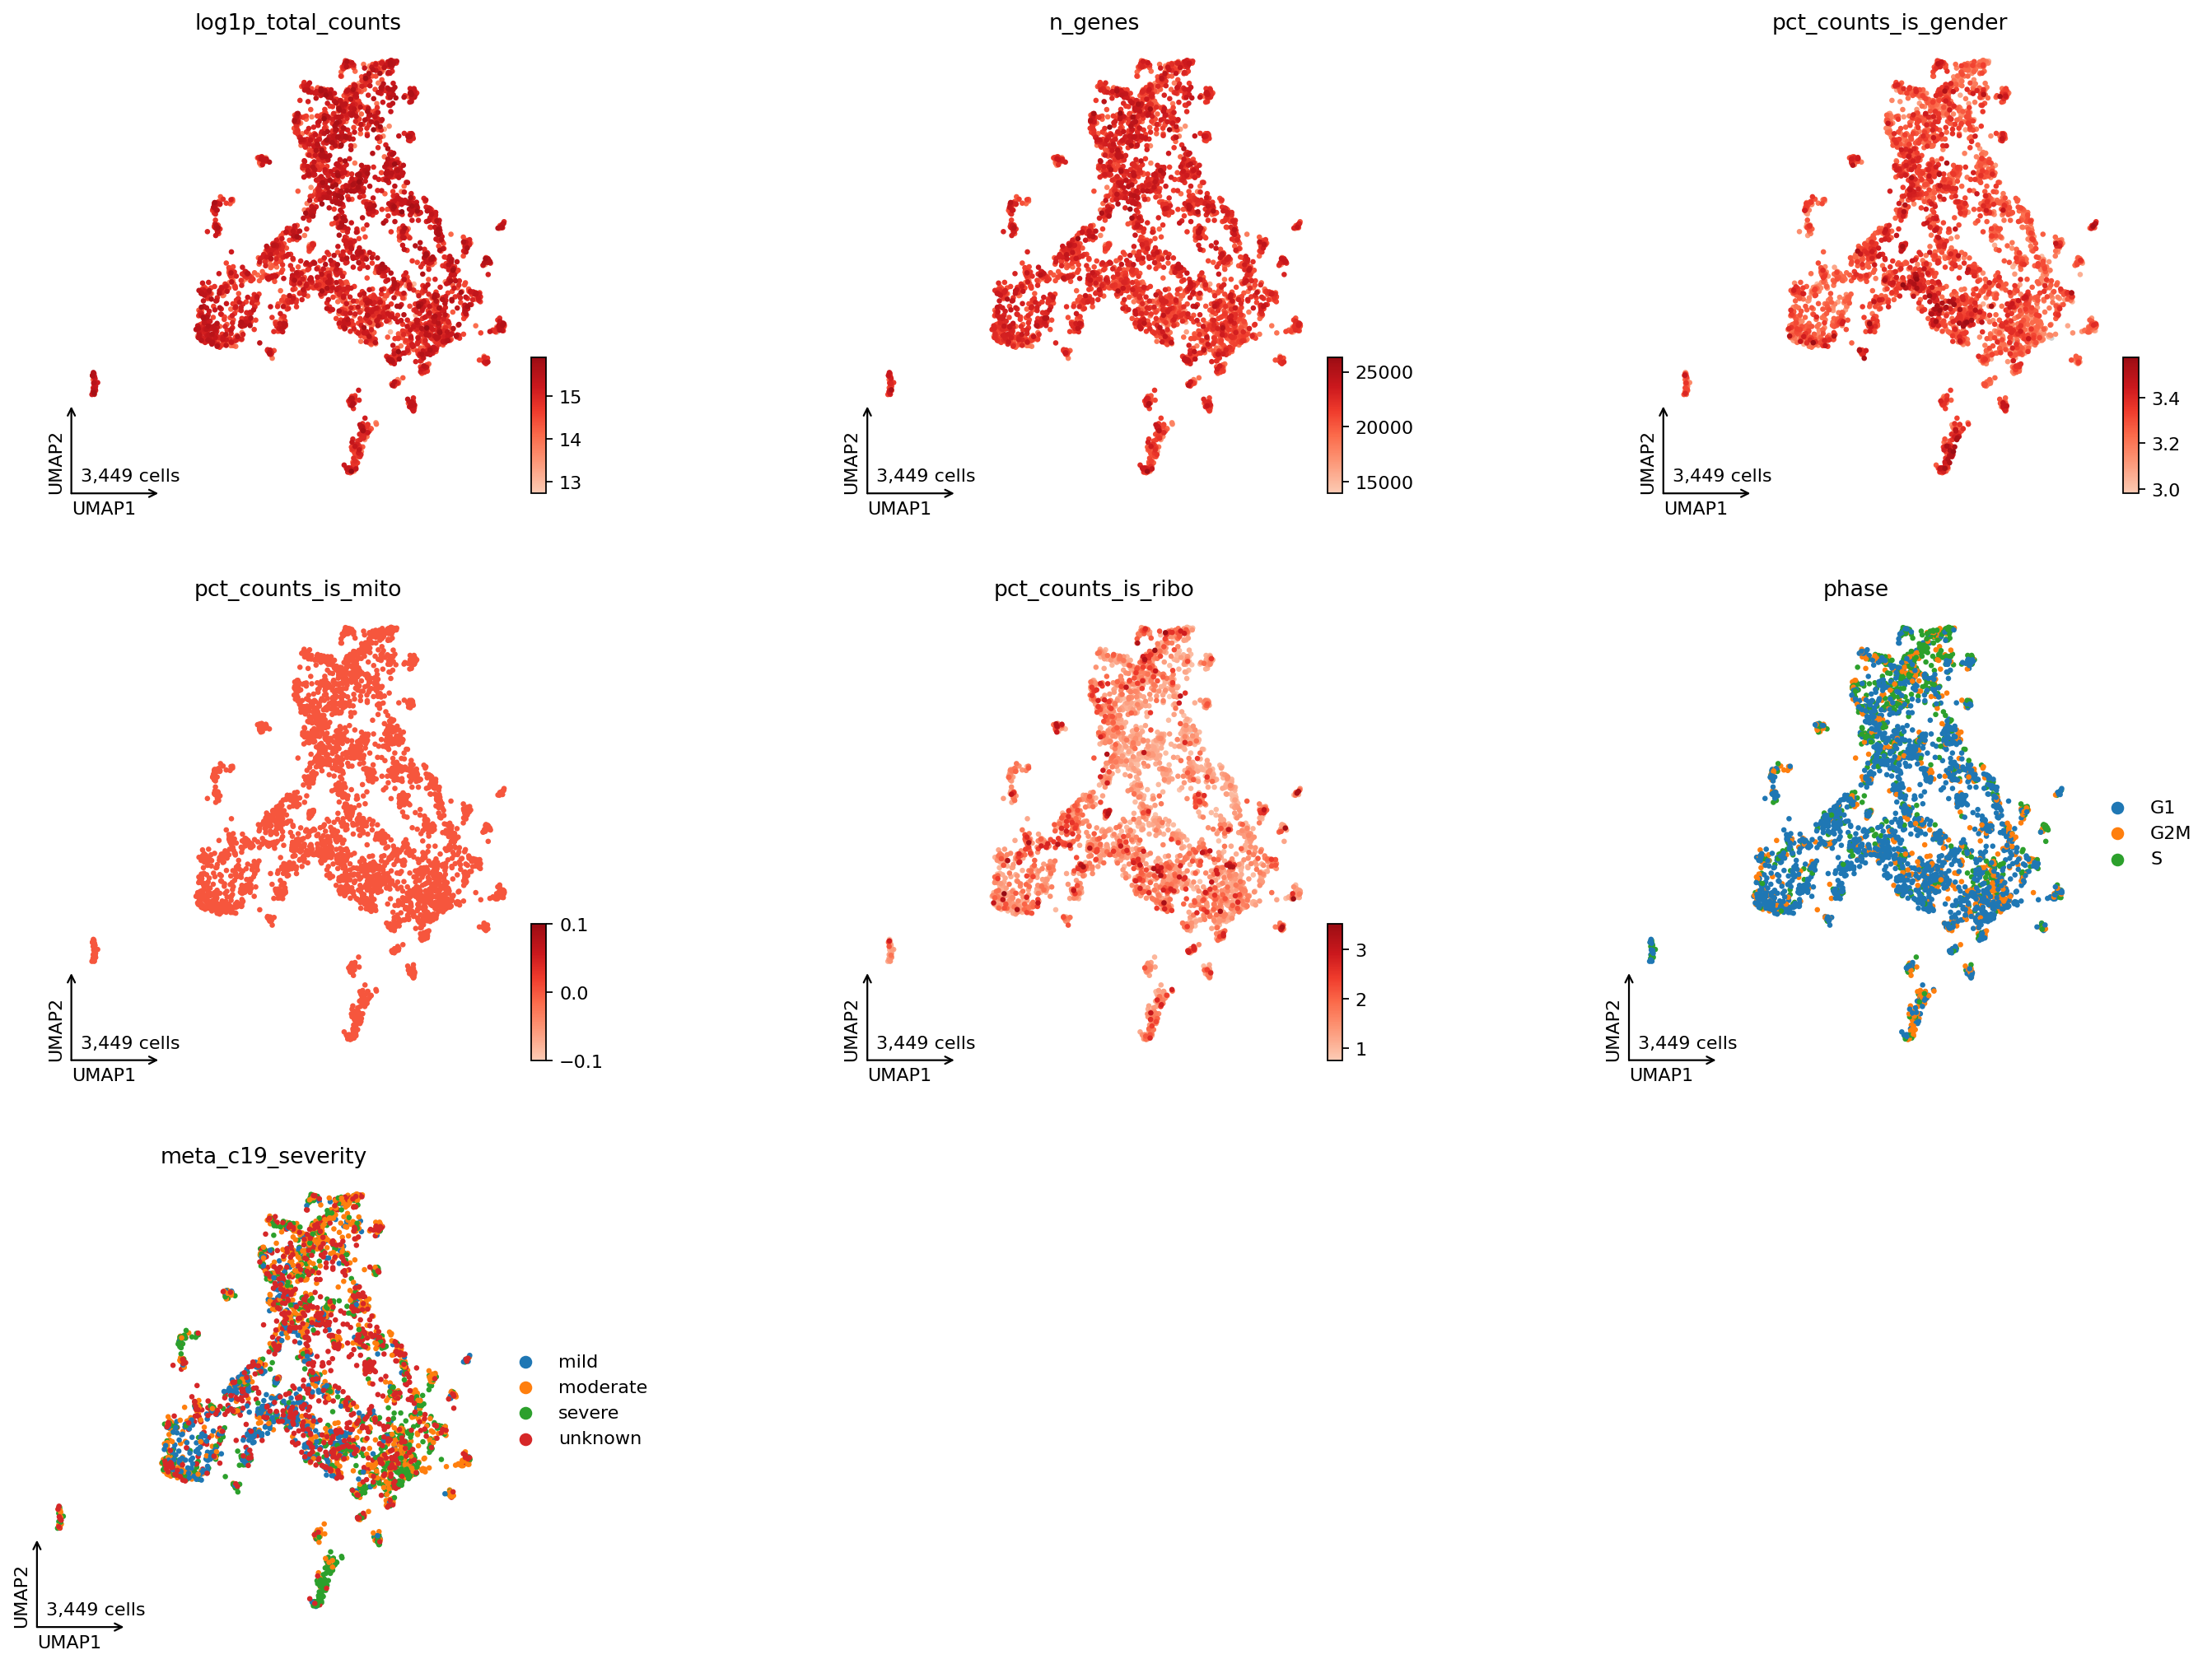

In [10]:
# Plot final umap/tsne with quality measures
_ = pl.embedding.plot_embedding(adata, method=embedding, color=qc_columns, ncols=3, save="embedding_quality.pdf")

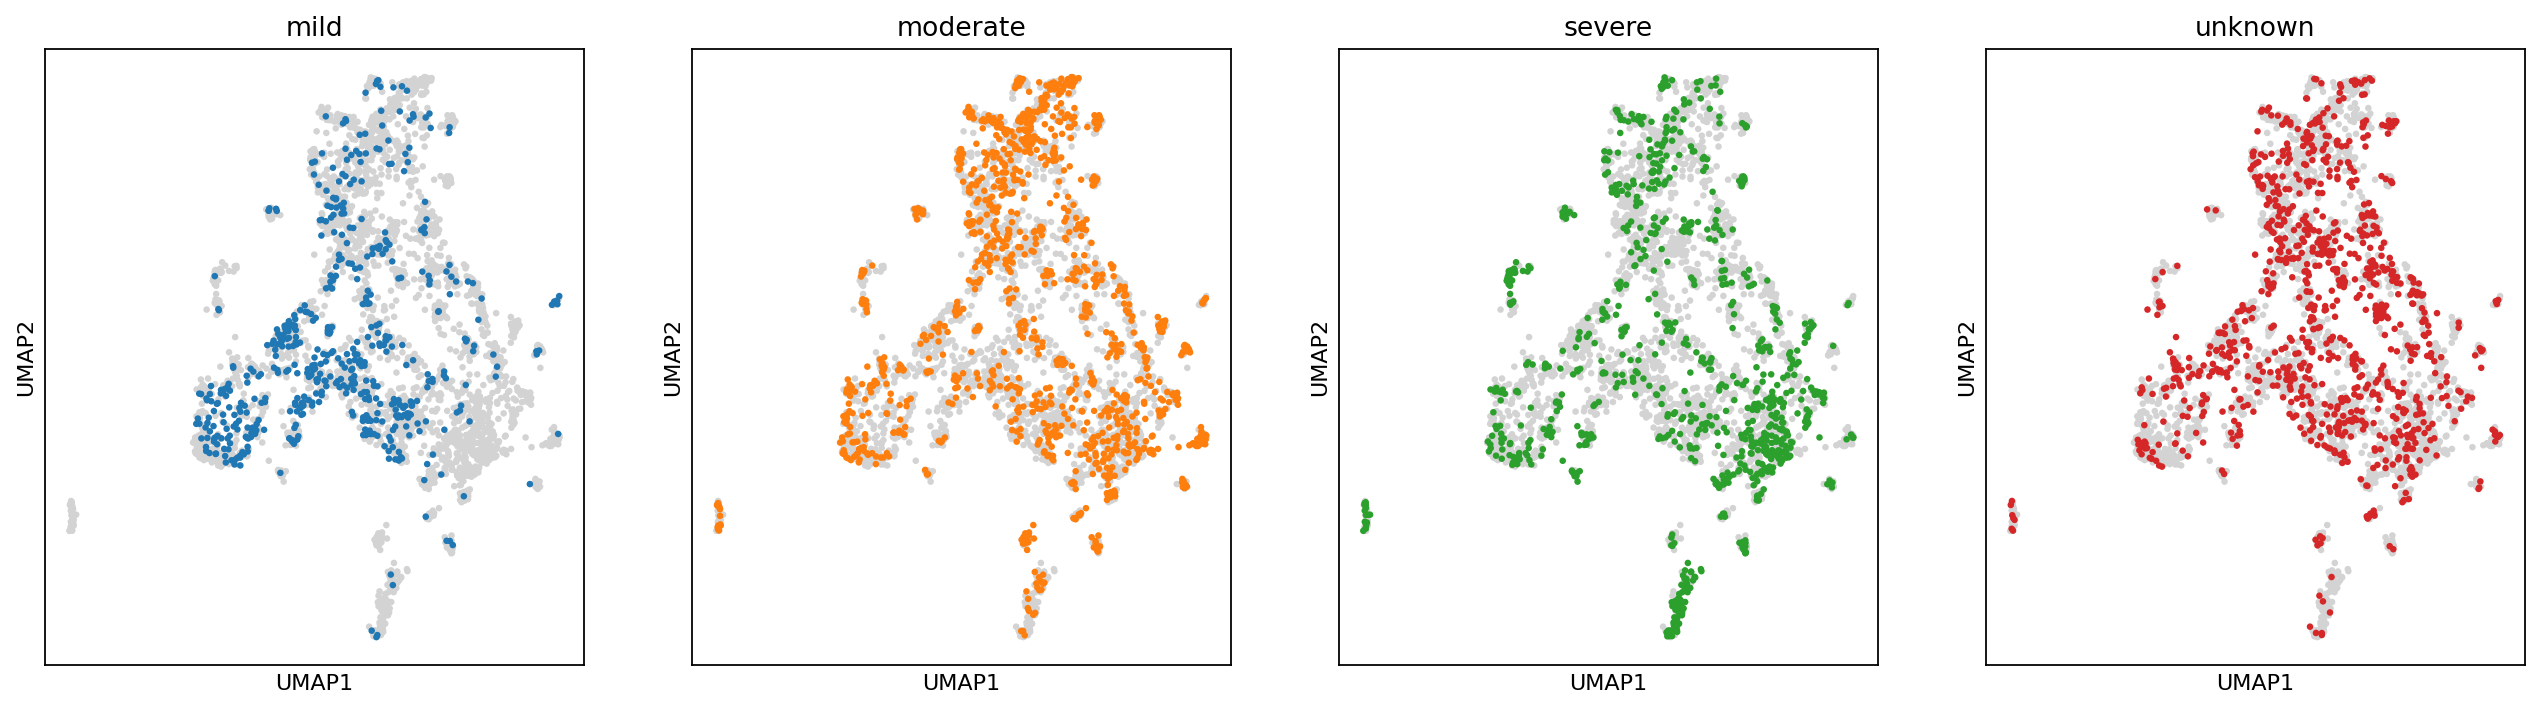

In [11]:
# Plot distribution of samples in embedding
_ = pl.embedding.plot_group_embeddings(
    adata,
    groupby=condition_column,
    embedding=embedding,
    save="embedding_sample_distribution.pdf"
)

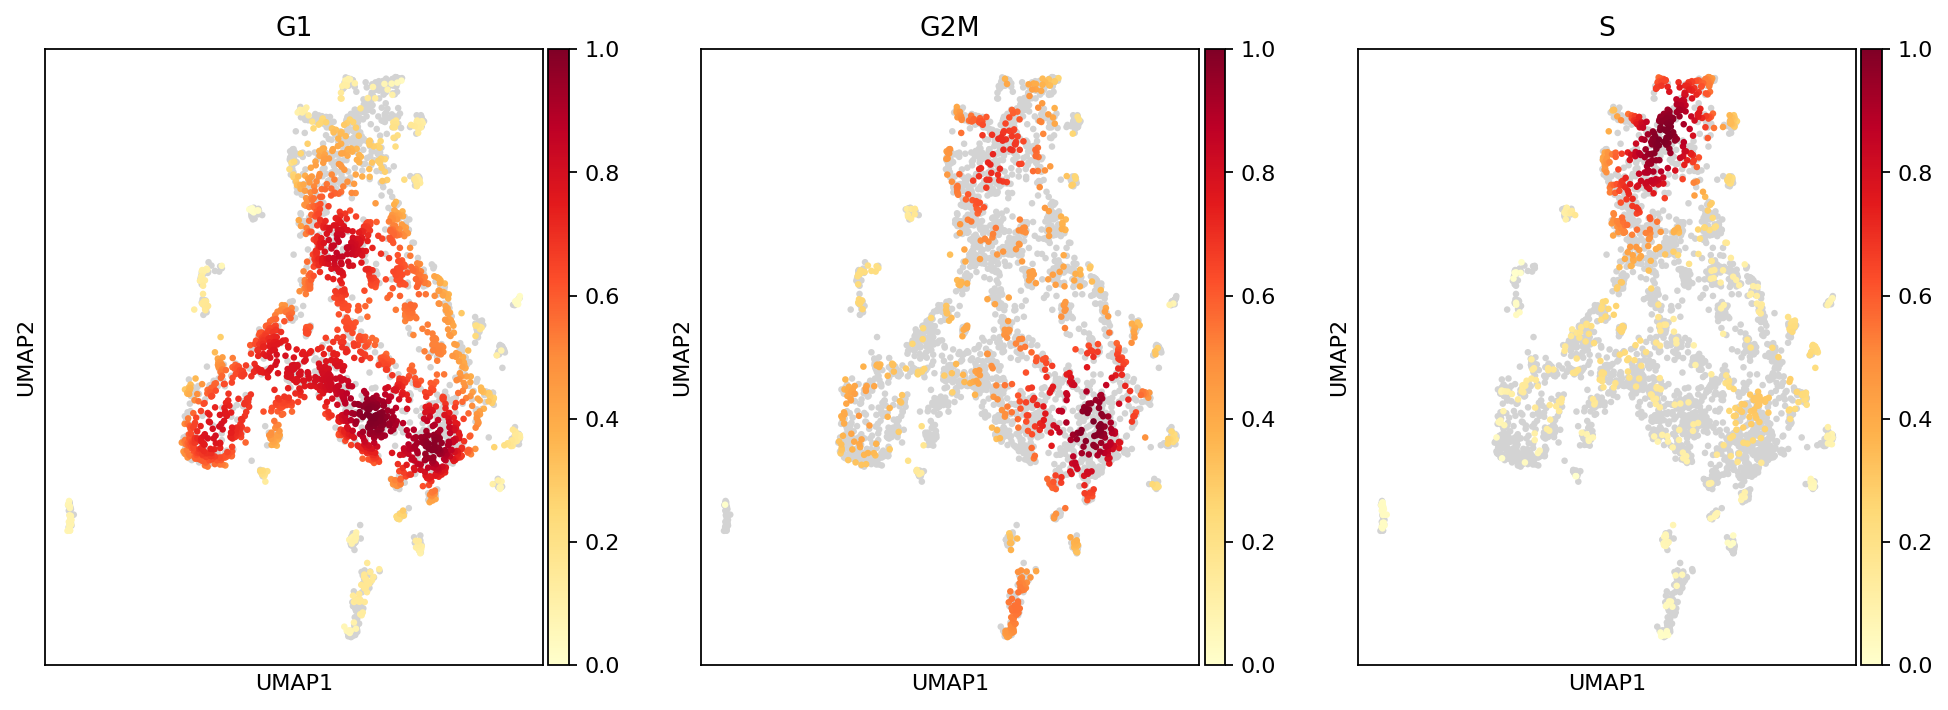

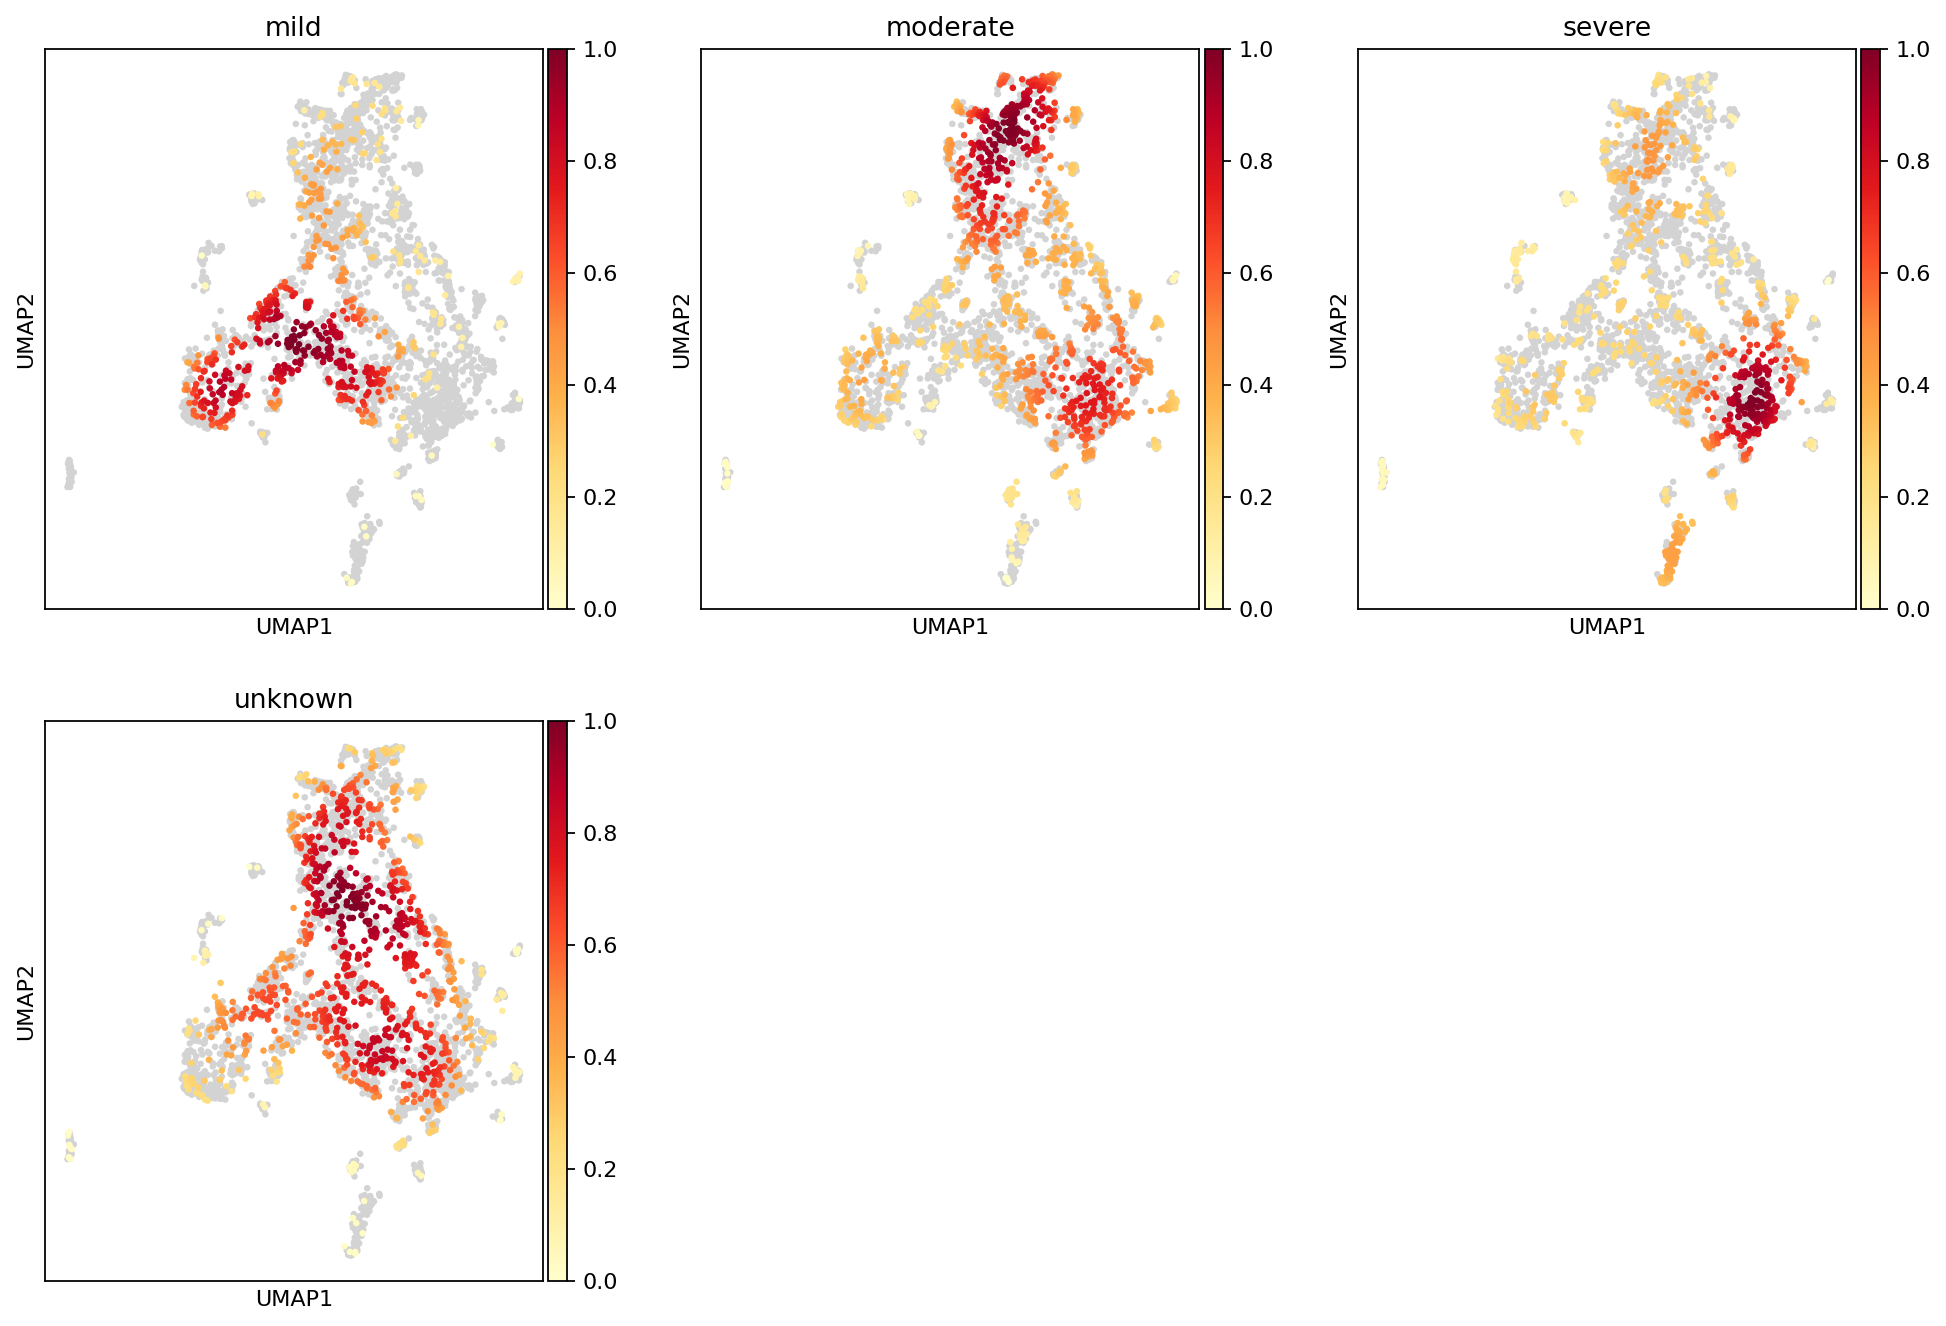

In [12]:
# Plot density of categorical QC columns
for qc_col in qc_columns:
    if qc_col in adata.obs.select_dtypes(exclude="number").columns:
        sc.tl.embedding_density(adata, basis=embedding, groupby=qc_col, key_added=f"{qc_col}_density")
        pl.embedding.plot_group_embeddings(adata, col=f"{qc_col}_density", groupby=qc_col,
                                           embedding=embedding, ncols=3, color_map="YlOrRd",
                                           save=f"embedding_density_{qc_col}.pdf")

/home/stud11/.conda/envs/sctoolbox/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:429: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/stud11/.conda/envs/sctoolbox/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/stud11/.conda/envs/sctoolbox/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:434: Perform

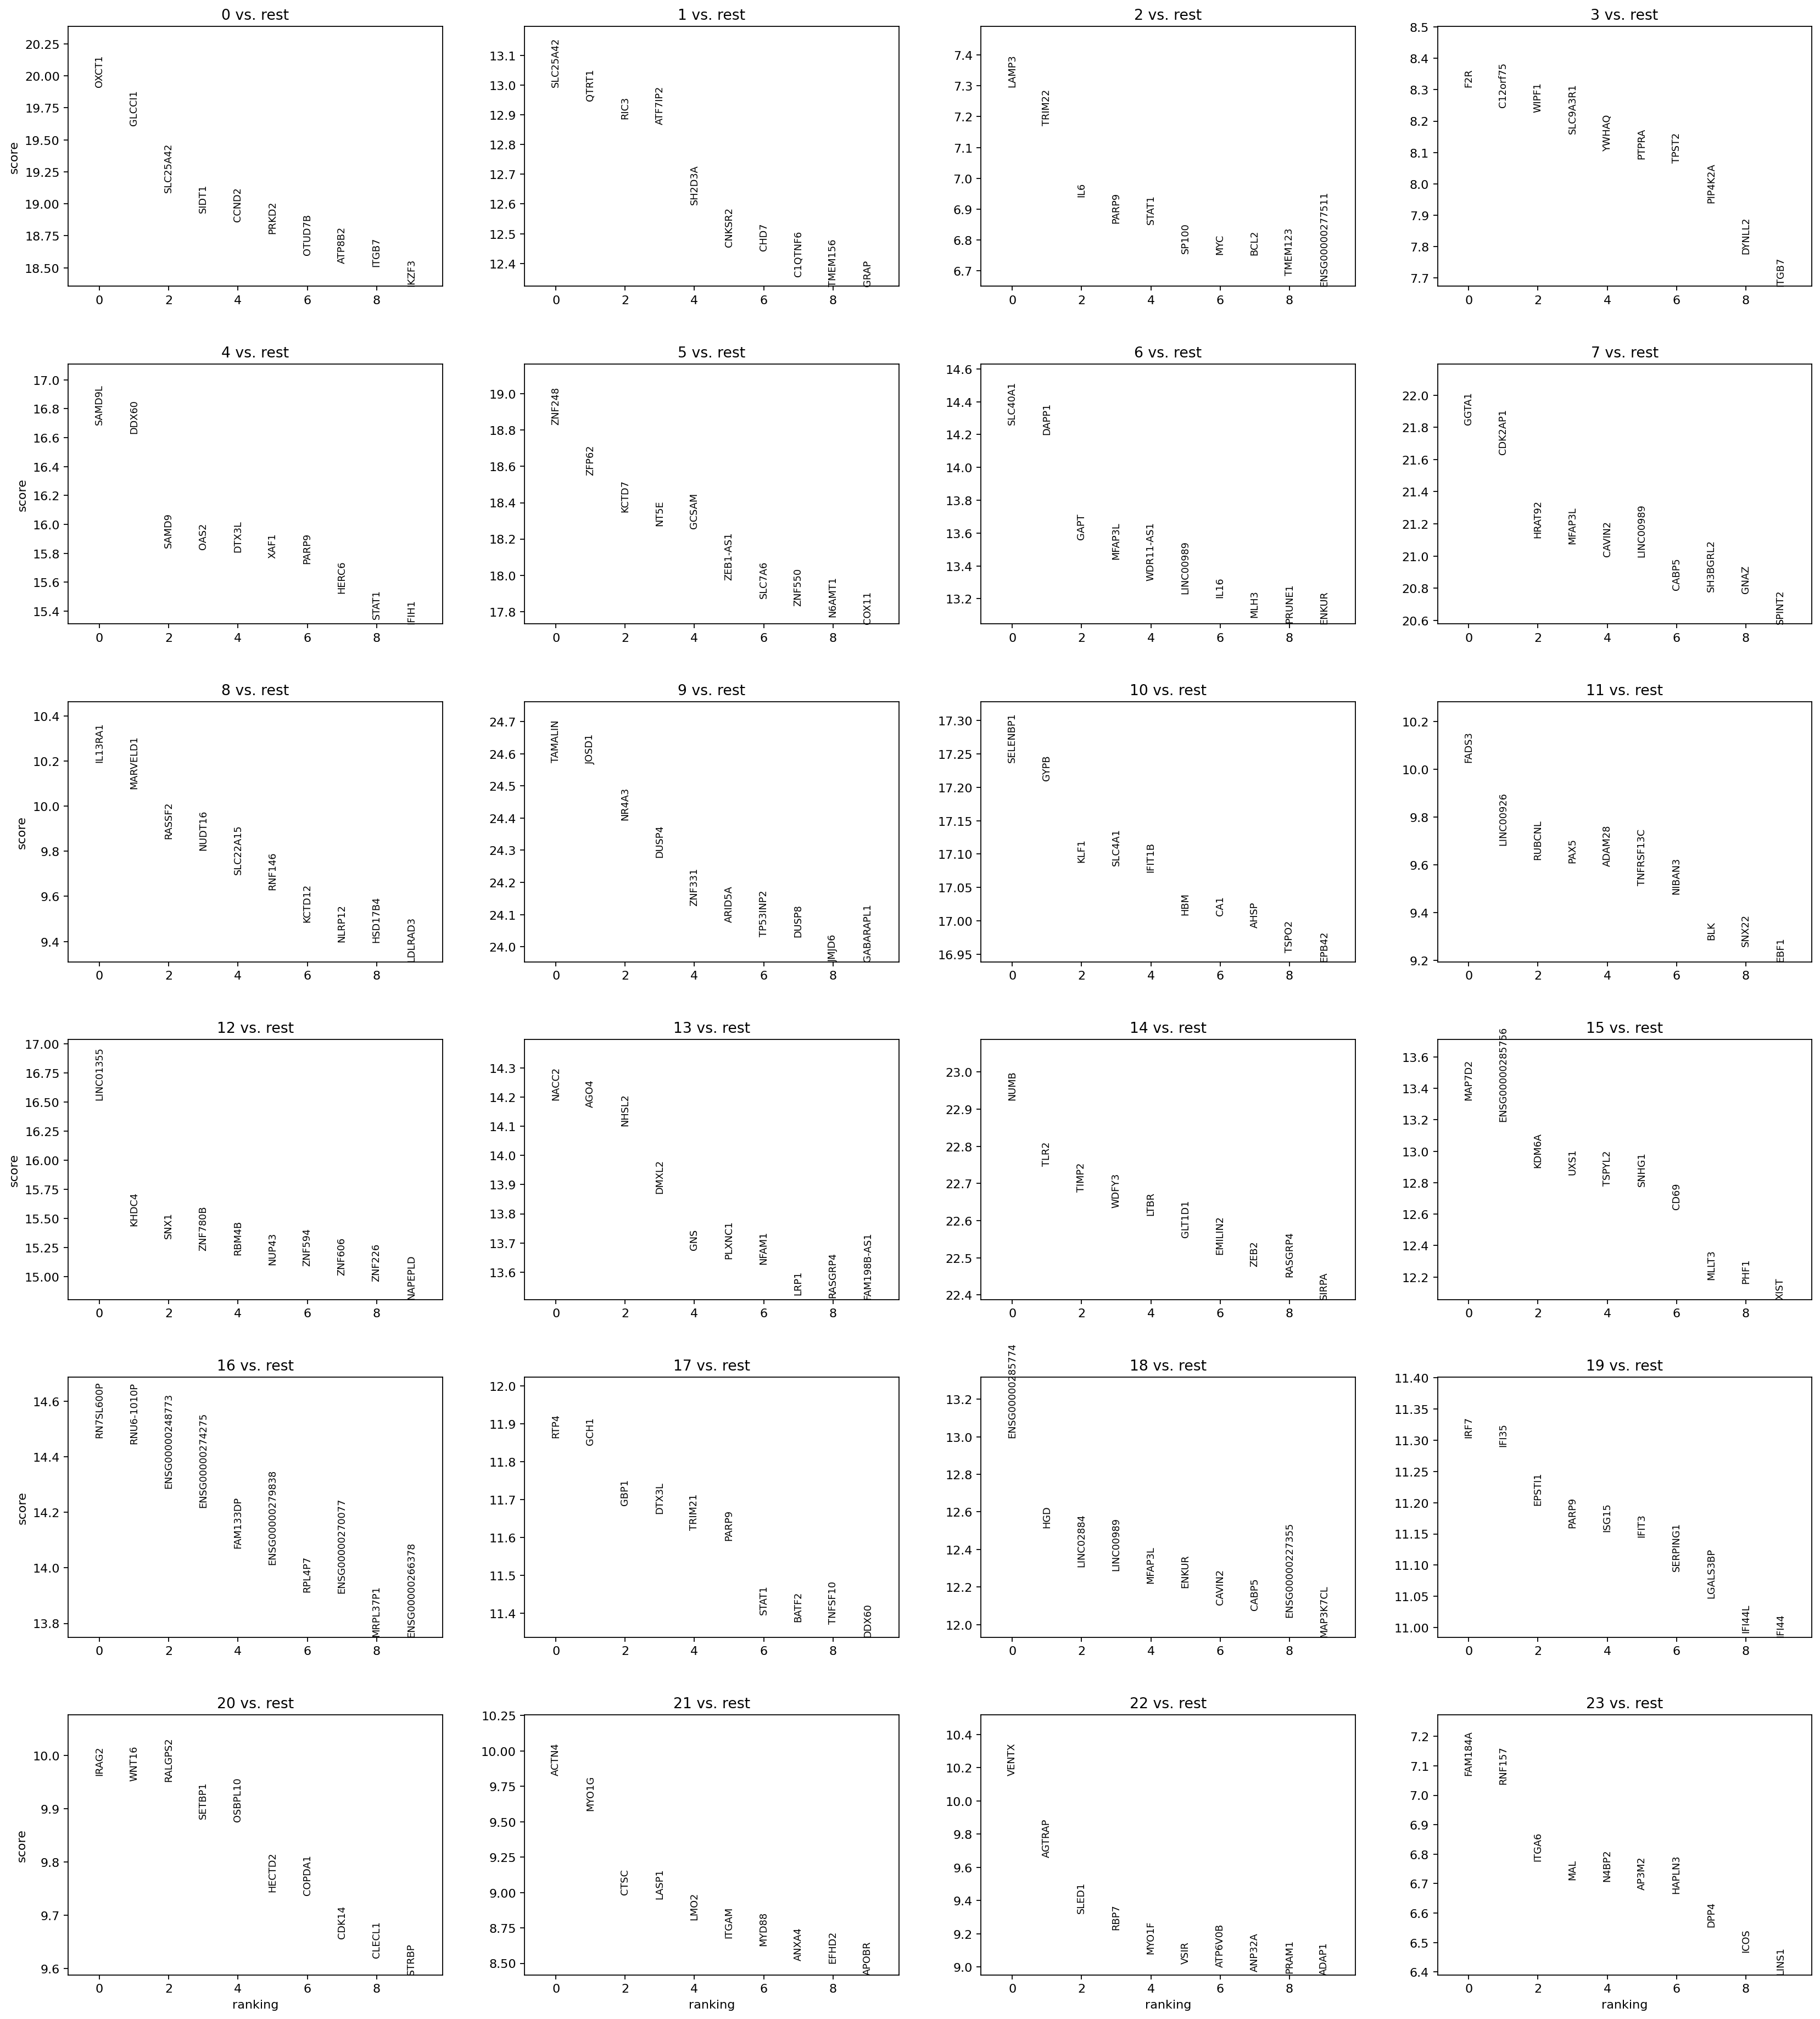

In [30]:
import scanpy as sc

sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)

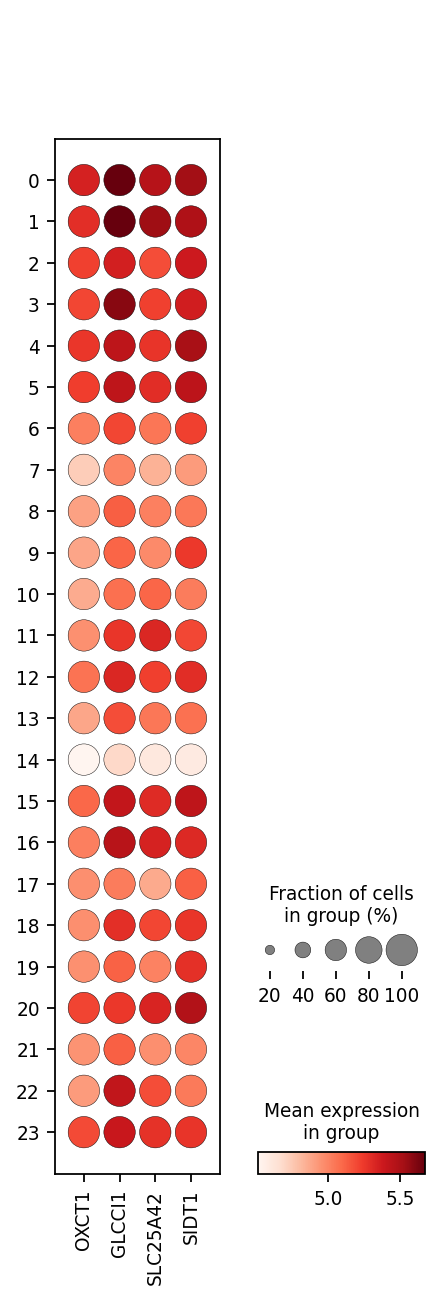

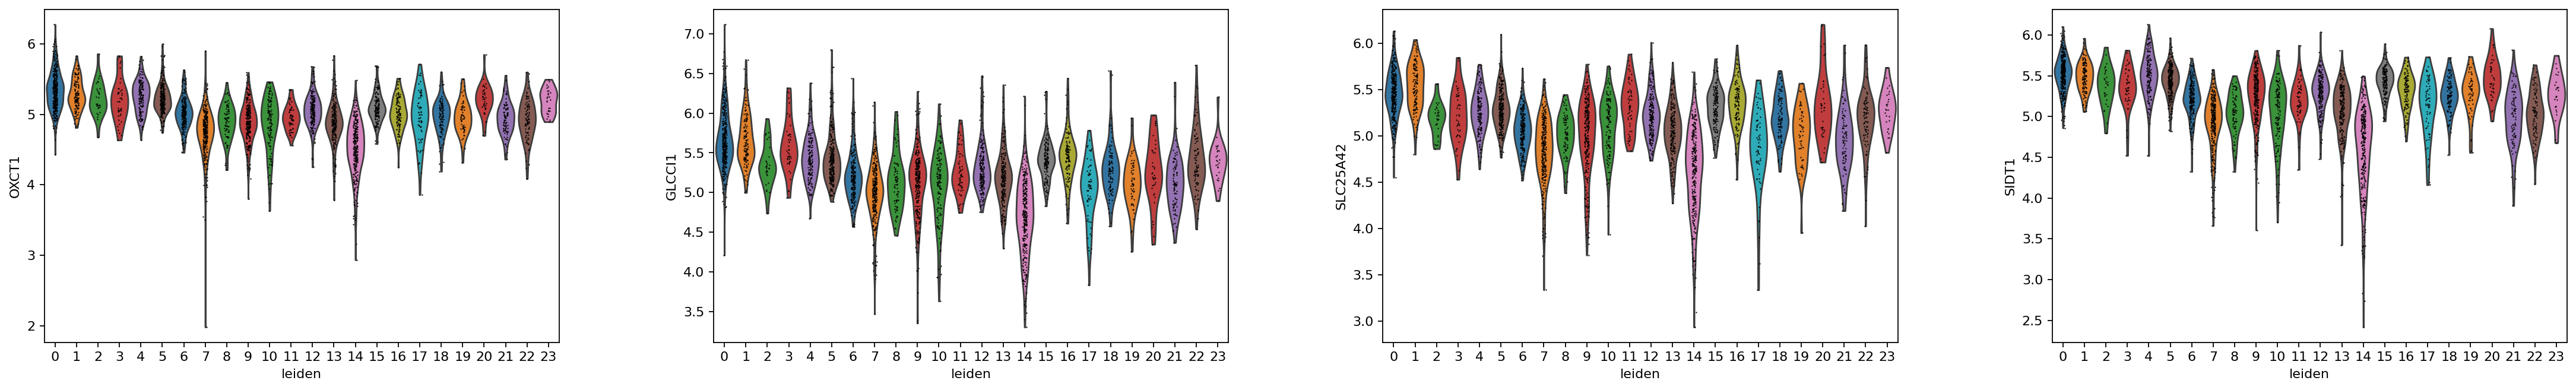

In [31]:
marker_genes = ["OXCT1", "GLCCI1", "SLC25A42", "SIDT1"]
sc.pl.dotplot(adata, marker_genes, groupby="leiden")
sc.pl.violin(adata, marker_genes, groupby="leiden")

----------

## 7 - Cell clustering
<hr style="border:2px solid black"> </hr>

This step assigns each cell into a cluster. Cells in the same cluster are assumed to be of the same cell type. Cells are assigned based on their distance within the nearest neighbor graph, which is loosely equivalent to their distance within the embedding. The resolution controls the coarseness of the clustering. A lower resolution results in fewer larger clusters, while a higher resolution results in more smaller clusters.

- `clustering_column`: To choose a resolution, change the number in `leiden_0.5`, for example `leiden_0.1` for a resolution of `0.1`. Higher values lead to more clusters.

[INFO] Plotting umap for resolution=0.1 (1 / 9)
[INFO] Plotting umap for resolution=0.2 (2 / 9)
[INFO] Plotting umap for resolution=0.3 (3 / 9)
[INFO] Plotting umap for resolution=0.4 (4 / 9)
[INFO] Plotting umap for resolution=0.5 (5 / 9)
[INFO] Plotting umap for resolution=0.6 (6 / 9)
[INFO] Plotting umap for resolution=0.7 (7 / 9)
[INFO] Plotting umap for resolution=0.8 (8 / 9)
[INFO] Plotting umap for resolution=0.9 (9 / 9)


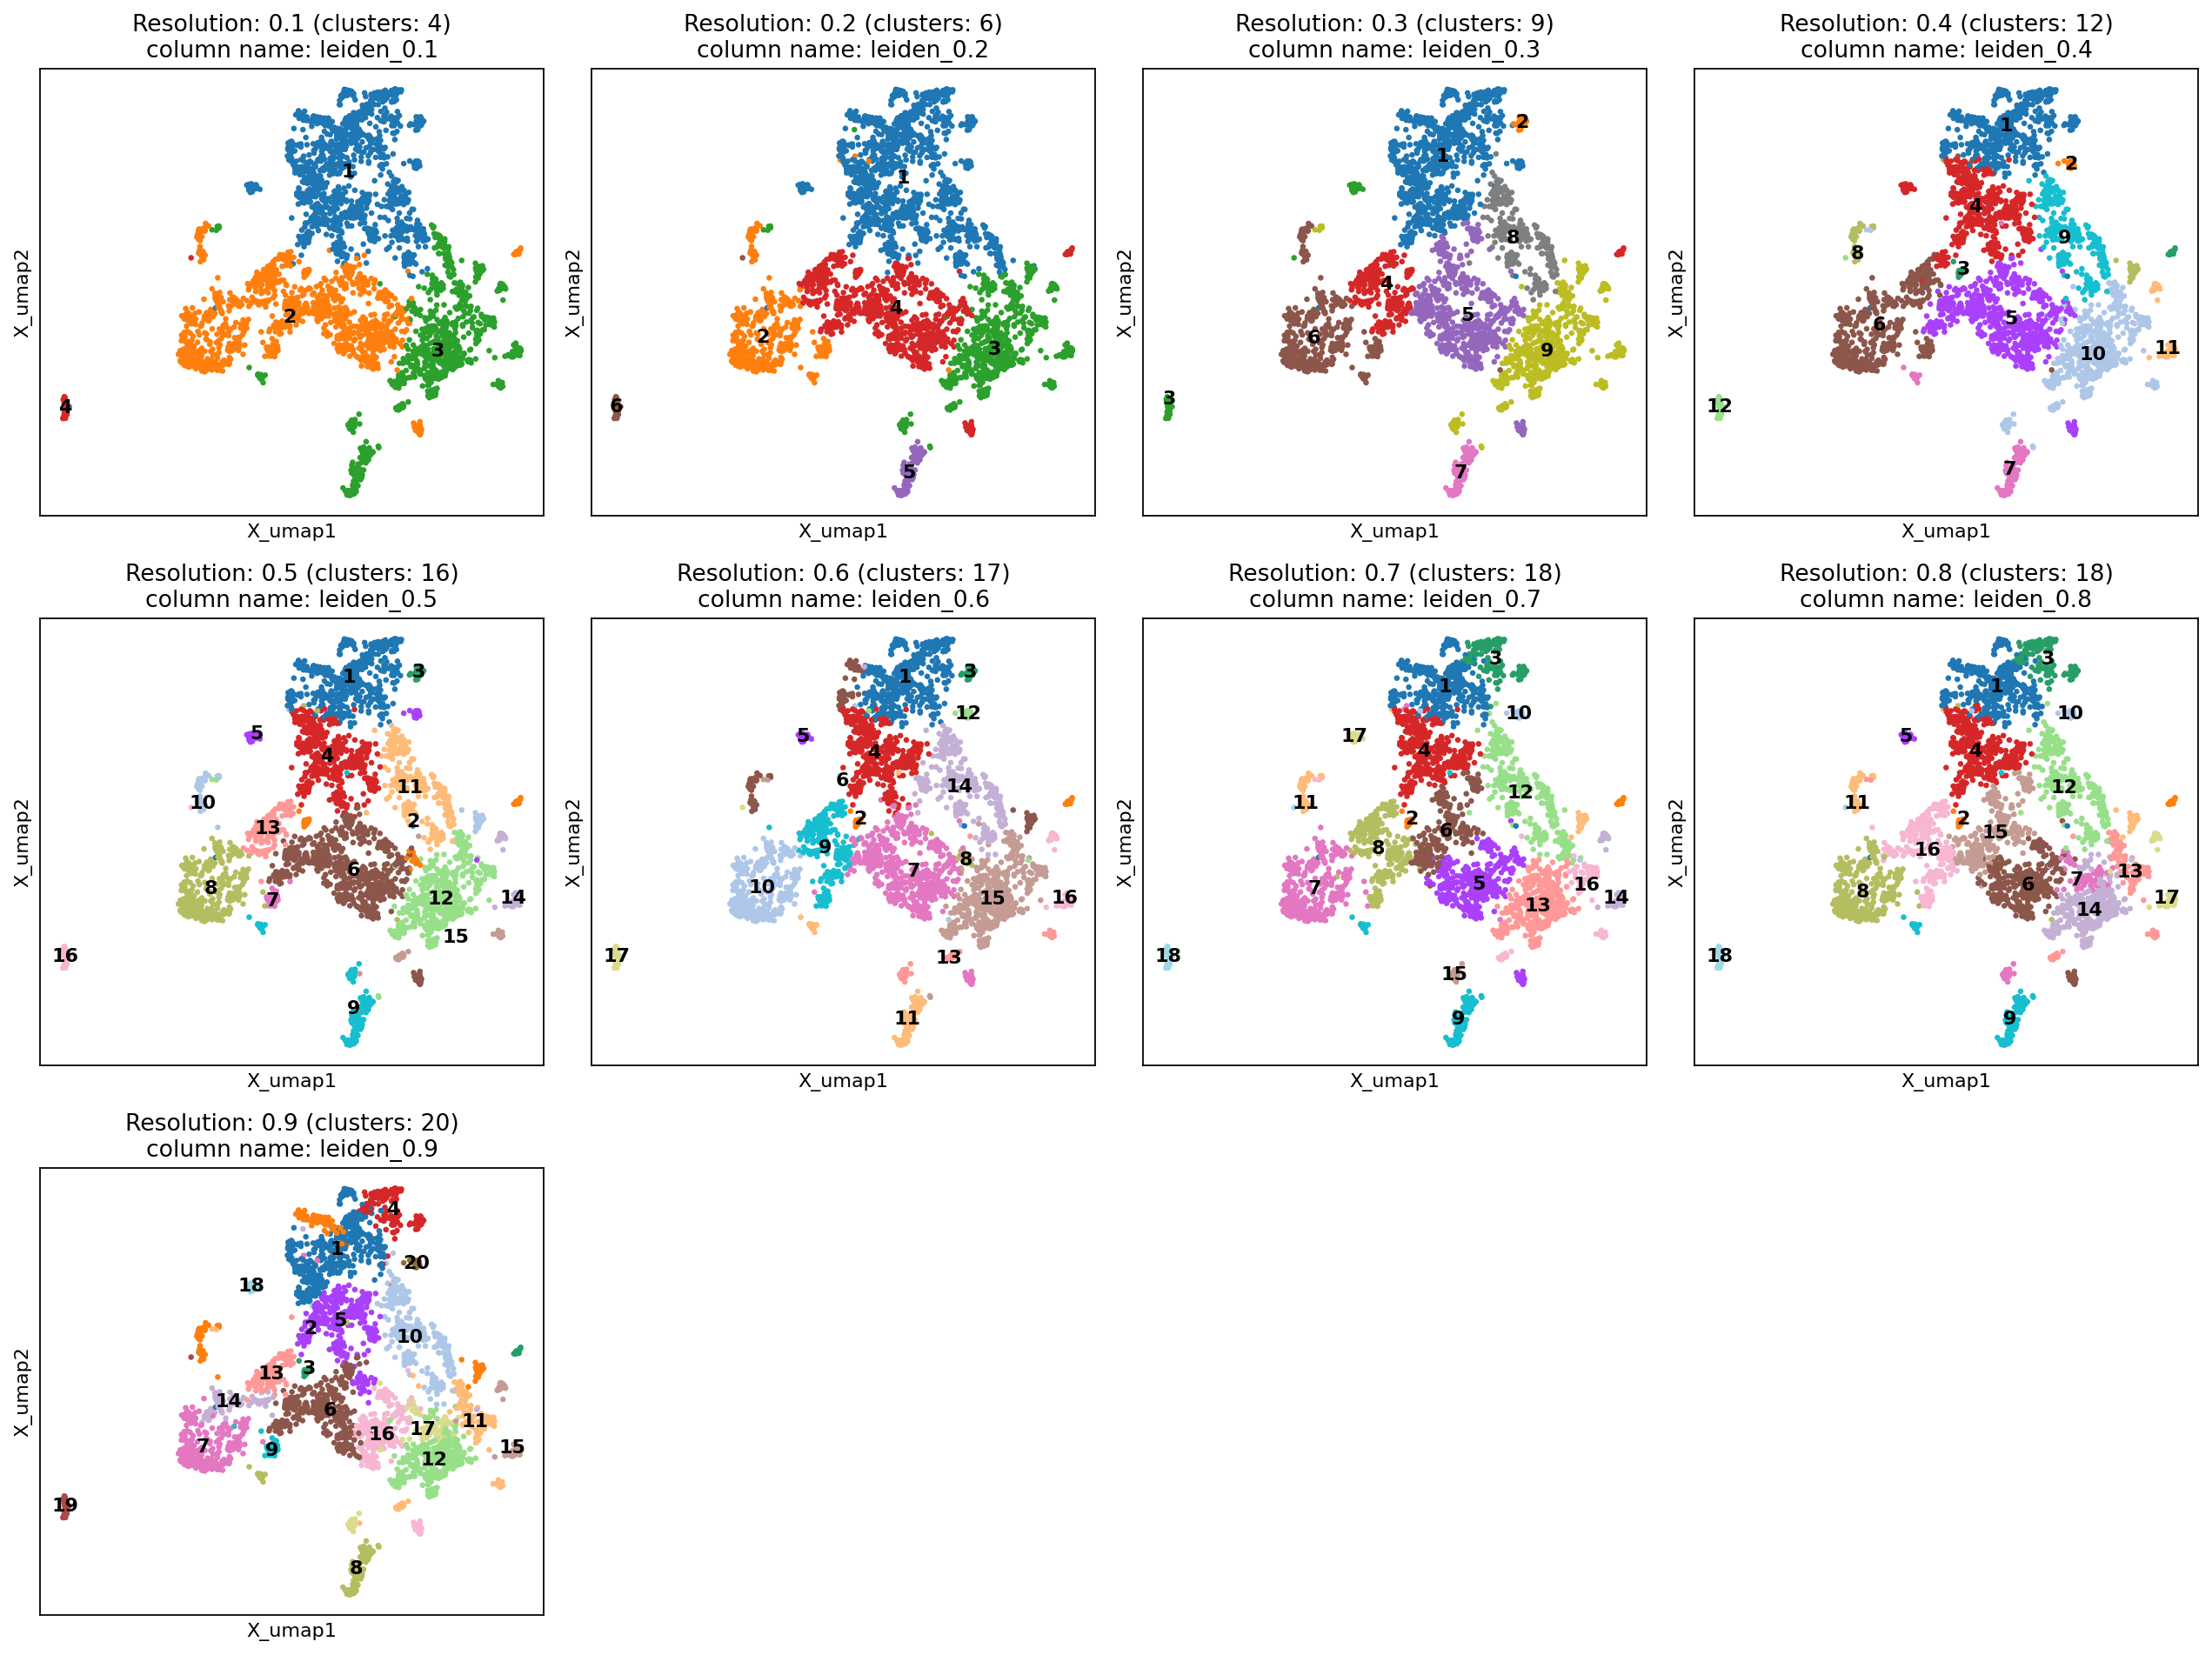

In [13]:
if search_clustering_parameters:
    pl.clustering.search_clustering_parameters(
        adata,
        ncols=cluster_ncols,
        method=clustering_method, 
        embedding=embedding,
        resolution_range=cluster_res_range,
        save="clustering_search.png")

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [32]:
# Choose final resolution
clustering_column = "leiden_0.7"

___

### 7.1 - Revise clustering (optional)
Here you can use the `tools.clustering.recluster` function to iteratively adjust clustering. The two cells below are provided as a template for either *joining* clusters (first cell) or *splitting* clusters (second cell). Fill in the list at the top of the respective cell to activate *joining* or *splitting*. You can __copy the cells as needed__ for more combining and splitting steps.

In [33]:
# combine multiple clusters into one
# skipped when empty
combine = [] # add cluster names

if combine:
    tools.clustering.recluster(
        adata=adata,
        column=clustering_column,
        clusters=combine,
        task="join",
        embedding=embedding,
        key_added="recluster"
    )

    clustering_column = "recluster"

In [34]:
# split (recluster) one or more clusters
# skipped when empty
split = []  # add cluster names
resolution = 0.15  # 0-1, small values create less clusters

if split:
    tools.clustering.recluster(
        adata=adata, 
        column=clustering_column,
        clusters=split,
        task="split",
        resolution=resolution,
        embedding=embedding,
        key_added="recluster"
    )
    
    clustering_column = "recluster"

In [35]:
# Create final clustering
adata.obs["clustering"] = utils.tables.rename_categories(adata.obs[clustering_column])

___

### 7.2 - Final clustering of cells

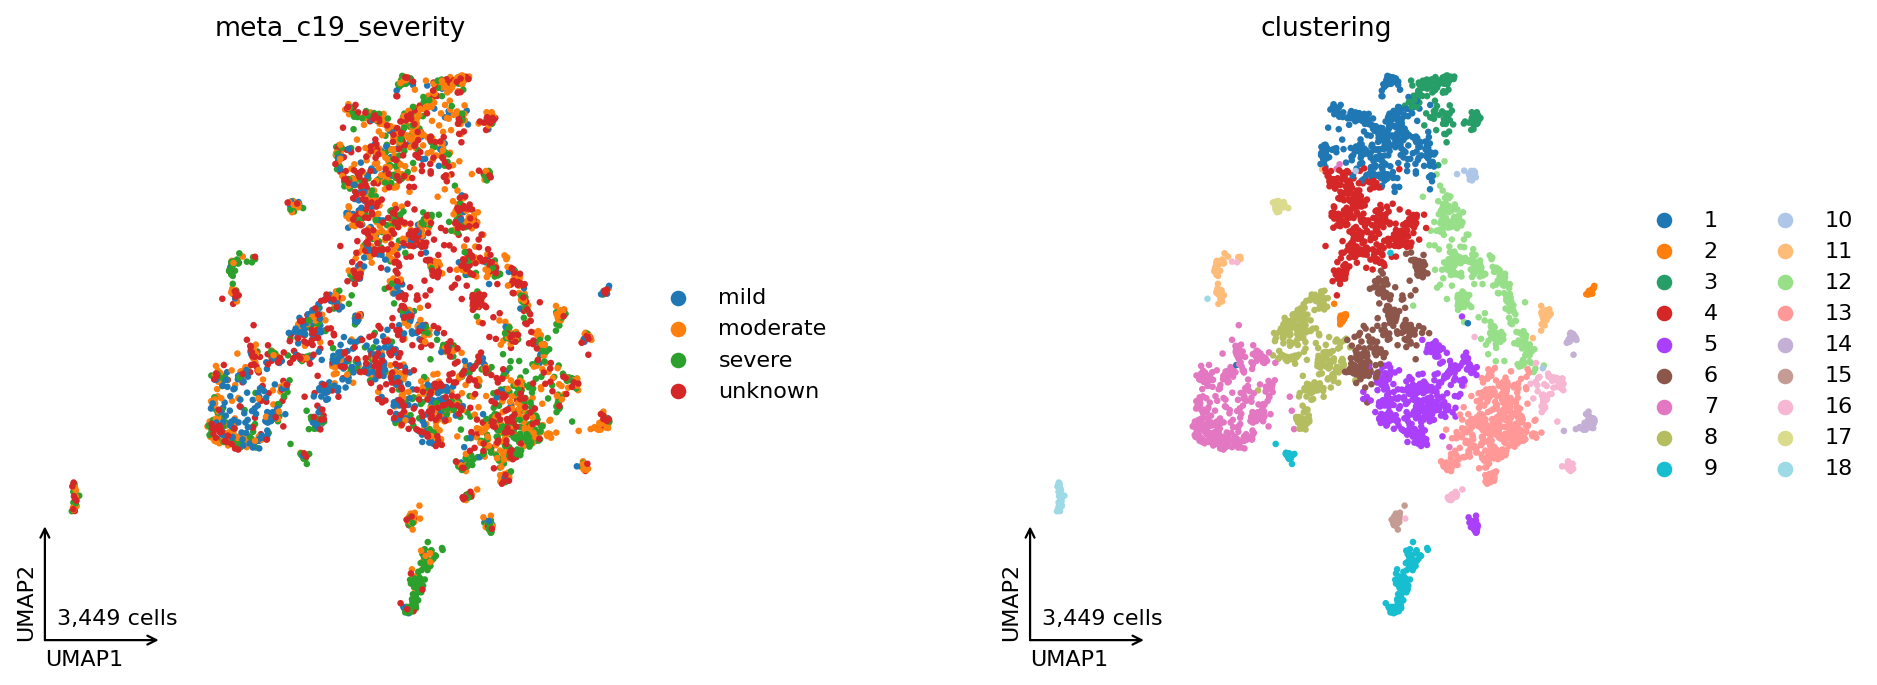

In [36]:
# Plot final leiden
_ = pl.embedding.plot_embedding(adata, method=embedding, color=[condition_column, "clustering"], save="embedding_clustering.pdf")

---------

## 8 - Plot distribution of cells across clusters

In [ ]:
_ = pl.qc_filter.n_cells_barplot(
    adata,
    "clustering",
    groupby=condition_column,
    save="cell_distribution_barplot.pdf"
)

------

## 9 - Generating 3D Object with UMAP coordinates in HTML

This optional step can be used to create a 3 dimensional UMAP. However, this is **disabled by default** since the process of optimizing in the 3D or higher dimensional space usually **degrades lower dimensional (2D) representation of the UMAP**. Set `n_components` >= 3 at the top of the notebook to enable this step but be aware of the implications.

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [25]:
# plot 3D html for the "clustering" adata.obs, change to individual leiden or other columns if needed
column_3d = "clustering"

___

In [27]:
if embedding == "umap" and n_components > 2:
    pl.embedding.plot_3D_UMAP(adata, column_3d, save=f"umap_3d_{column_3d}")
    html_file = sctoolbox.settings.full_figure_prefix + f"umap_3d_{column_3d}.html"
    
    from IPython.display import IFrame
    display(IFrame(src=html_file, width=800, height=400))

---------

## 10 - Saving adata for next notebook

In [28]:
utils.adata.save_h5ad(adata, "anndata_4.h5ad")

[INFO] The adata object was saved to: ../adatas/anndata_4.h5ad


In [29]:
sctoolbox.settings.close_logfile()